In [14]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower


In [2]:
trainset = pd.read_csv("../trainset.csv")

In [3]:
trainset.head()

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,tamano_manguito_pa_4.0,tamano_manguito_pa_5.0,estado_elastografia_1,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL',raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
print(trainset.shape)

(1919, 69)


In [5]:
trainset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 69 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad_an                         1919 non-null   float64
 1   tamano_hogar                    1919 non-null   float64
 2   psu                             1919 non-null   float64
 3   ratio_pobreza                   1919 non-null   float64
 4   tiempo_seg_cond1                1919 non-null   float64
 5   tiempo_seg_cond2                1919 non-null   float64
 6   tiempo_seg_cond3                1919 non-null   float64
 7   tiempo_seg_cond4                1919 non-null   float64
 8   pulso                           1919 non-null   float64
 9   peso_kg                         1919 non-null   float64
 10  altura_cm                       1919 non-null   float64
 11  imc                             1919 non-null   float64
 12  largo_pierna_superior_cm        19

In [ ]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset.columns]


print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 0
[]
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl', 'volumen_corpuscular_medio', 'conc_hemoglobina_media', 'ancho_distribucion_eritrocitos', 'plaquetas_totales', 'volumen_plaquetario_medio', 'trigliceridos_mmol_l', 'ldl_martin_mmol_l', 'hdl_mmol_l', 'plomo_sangre_umol_l', 'cadmio_sangre_nmol_l', 'mercurio_sangre_nmol_l', 'selenio_sangre_umol_l', 

In [10]:
var_categoricas=['genero_1', 'periodo_examen_1', 'pais_nacimiento_1', 'toma_suplementos_1',
 'toma_antiacidos_1', 'estado_examen_balance_1', 'elegibilidad_balance_1',
 'convulsiones_1', 'caidas_1', 'fracturas_1', 'medicacion_osteoporosis_1',
 'aprueba_cond4_1', 'tamano_manguito_pa_3.0', 'tamano_manguito_pa_4.0',
 'tamano_manguito_pa_5.0', 'estado_elastografia_1', "tipo_sonda_elasto_b'M'",
 "tipo_sonda_elasto_b'XL'", 'raza_etnia_2.0', 'raza_etnia_3.0',
 'raza_etnia_4.0', 'raza_etnia_6.0', 'raza_etnia_7.0']

trainset[var_categoricas] = trainset[var_categoricas].astype('object')

print(trainset[var_categoricas].dtypes)
print (f"Número de columnas categóricas: {len(var_categoricas)}")

genero_1                     object
periodo_examen_1             object
pais_nacimiento_1            object
toma_suplementos_1           object
toma_antiacidos_1            object
estado_examen_balance_1      object
elegibilidad_balance_1       object
convulsiones_1               object
caidas_1                     object
fracturas_1                  object
medicacion_osteoporosis_1    object
aprueba_cond4_1              object
tamano_manguito_pa_3.0       object
tamano_manguito_pa_4.0       object
tamano_manguito_pa_5.0       object
estado_elastografia_1        object
tipo_sonda_elasto_b'M'       object
tipo_sonda_elasto_b'XL'      object
raza_etnia_2.0               object
raza_etnia_3.0               object
raza_etnia_4.0               object
raza_etnia_6.0               object
raza_etnia_7.0               object
dtype: object
Número de columnas categóricas: 23


In [11]:
X_train = trainset.select_dtypes(include=['number'])
X_train.shape

(1919, 46)

In [12]:
silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    silhouette_scores[k] = score
    print(f"Para K={k}, el Silhouette Score es: {score:.4f}")

Para K=2, el Silhouette Score es: 0.1010
Para K=3, el Silhouette Score es: 0.0510
Para K=4, el Silhouette Score es: 0.0432
Para K=5, el Silhouette Score es: 0.0492


In [13]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nEl K óptimo según el Silhouette Score es: K={best_k} (Score: {silhouette_scores[best_k]:.4f})")


El K óptimo según el Silhouette Score es: K=2 (Score: 0.1010)


USANDO K-PROTOTYPES

In [15]:
cat_indices = [trainset.columns.get_loc(col) for col in var_categoricas]
print(f"Índices de columnas categóricas: {cat_indices}")
print(f"Columnas categóricas: {len(cat_indices)}")

Índices de columnas categóricas: [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]
Columnas categóricas: 23


In [18]:
matriz_datos = trainset.to_numpy()

In [19]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset)

Calculando la matriz de Distancia de Gower...


In [20]:
# 3. Evaluar K entre 2 y 5
resultados_silhouette = {}
mejor_k = -1
mejor_score = -1

print("\nEntrenando K-Prototypes y calculando Silhouette Scores:")
for k in range(2, 6):
    # Entrenar K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', n_jobs=-1, random_state=42)
    etiquetas_clusters = kproto.fit_predict(matriz_datos, categorical=cat_indices)
    
    # Calcular Silhouette Score usando la matriz de Gower precalculada
    # metric='precomputed' le dice a sklearn que no intente calcular distancias euclidianas
    score = silhouette_score(matriz_distancias_gower, etiquetas_clusters, metric='precomputed')
    
    resultados_silhouette[k] = score
    print(f"Para K={k} -> Silhouette Score (Gower): {score:.4f}")
    
    # Guardar el mejor resultado
    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# 4. Mostrar el veredicto final
print("-" * 40)
print(f"El conjunto óptimo es K = {mejor_k} con un Silhouette Score de {mejor_score:.4f}")


Entrenando K-Prototypes y calculando Silhouette Scores:
Para K=2 -> Silhouette Score (Gower): 0.1016
Para K=3 -> Silhouette Score (Gower): 0.0887
Para K=4 -> Silhouette Score (Gower): 0.0693
Para K=5 -> Silhouette Score (Gower): 0.0656
----------------------------------------
El conjunto óptimo es K = 2 con un Silhouette Score de 0.1016


Se han modificado los datasets para eliminar el proceso del OHE de cara a probar el metodo k-prototypes ya que si no estemetodo puede por ejemplo interpretar que hay 5 variables distintas de raza. Esto multiplicará por 5 la importancia matemática de la raza a la hora de agrupar pacientes.

In [28]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [29]:
trainset_no_ohe.head()

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,1,0,0,0,0,0,3.0,1,b'M',6.0


In [30]:
trainset_no_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad_an                         1919 non-null   float64
 1   tamano_hogar                    1919 non-null   float64
 2   psu                             1919 non-null   float64
 3   ratio_pobreza                   1919 non-null   float64
 4   tiempo_seg_cond1                1919 non-null   float64
 5   tiempo_seg_cond2                1919 non-null   float64
 6   tiempo_seg_cond3                1919 non-null   float64
 7   tiempo_seg_cond4                1919 non-null   float64
 8   pulso                           1919 non-null   float64
 9   peso_kg                         1919 non-null   float64
 10  altura_cm                       1919 non-null   float64
 11  imc                             1919 non-null   float64
 12  largo_pierna_superior_cm        19

In [31]:
trainset_no_ohe.shape

(1919, 62)

In [32]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas_no_ohe = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas_no_ohe = [col for col in cols_numericas if col in trainset_no_ohe.columns]


print(f"Número de columnas categóricas: {len(var_categoricas_no_ohe)}")
print(var_categoricas_no_ohe)

print(f"Número de columnas numéricas: {len(var_numericas_no_ohe)}")
print(var_numericas_no_ohe)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

In [33]:
cat_indices = [trainset_no_ohe.columns.get_loc(col) for col in var_categoricas_no_ohe]
print(f"Índices de columnas categóricas: {cat_indices}")
print(f"Columnas categóricas: {len(cat_indices)}")

Índices de columnas categóricas: [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
Columnas categóricas: 16


In [34]:
matriz_datos = trainset_no_ohe.to_numpy()

In [35]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Calculando la matriz de Distancia de Gower...


In [36]:
# 3. Evaluar K entre 2 y 5
resultados_silhouette = {}
mejor_k = -1
mejor_score = -1

print("\nEntrenando K-Prototypes y calculando Silhouette Scores:")
for k in range(2, 6):
    # Entrenar K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', n_jobs=-1, random_state=42)
    etiquetas_clusters = kproto.fit_predict(matriz_datos, categorical=cat_indices)
    
    # Calcular Silhouette Score usando la matriz de Gower precalculada
    # metric='precomputed' le dice a sklearn que no intente calcular distancias euclidianas
    score = silhouette_score(matriz_distancias_gower, etiquetas_clusters, metric='precomputed')
    
    resultados_silhouette[k] = score
    print(f"Para K={k} -> Silhouette Score (Gower): {score:.4f}")
    
    # Guardar el mejor resultado
    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# 4. Mostrar el veredicto final
print("-" * 40)
print(f"El conjunto óptimo es K = {mejor_k} con un Silhouette Score de {mejor_score:.4f}")


Entrenando K-Prototypes y calculando Silhouette Scores:
Para K=2 -> Silhouette Score (Gower): 0.0831
Para K=3 -> Silhouette Score (Gower): 0.0833
Para K=4 -> Silhouette Score (Gower): 0.0832
Para K=5 -> Silhouette Score (Gower): 0.0581
----------------------------------------
El conjunto óptimo es K = 3 con un Silhouette Score de 0.0833


OBSERVACIONES:

Se puede apreciar que al usar ambos metodos se obtienen unas metricas muy similares y muy pobres.

Esto puede deberse a que el numero de columnas es muy grande y el espacio geométrico se vuelve tan masivo que la distancia matemática entre cualquier par de pacientes se vuelve casi igual y por tanto el algoritmo no detecta densidades claras.

In [42]:
#comando de LIMPIEZA DE KERNEL PARA EVITAR QUE SE MEZCLEN VARIBALES DE DISTINTAS PRUEBAS
%reset -f
%reset -f in out dhist

Flushing input history
Flushing output cache (0 entries)
Flushing directory history


## Uso de PCA para reducción de dimensionalidad en el datsaset 

In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower
import numpy as np


In [4]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [5]:
trainset_no_ohe.shape

(1919, 62)

In [6]:
trainset_no_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad_an                         1919 non-null   float64
 1   tamano_hogar                    1919 non-null   float64
 2   psu                             1919 non-null   float64
 3   ratio_pobreza                   1919 non-null   float64
 4   tiempo_seg_cond1                1919 non-null   float64
 5   tiempo_seg_cond2                1919 non-null   float64
 6   tiempo_seg_cond3                1919 non-null   float64
 7   tiempo_seg_cond4                1919 non-null   float64
 8   pulso                           1919 non-null   float64
 9   peso_kg                         1919 non-null   float64
 10  altura_cm                       1919 non-null   float64
 11  imc                             1919 non-null   float64
 12  largo_pierna_superior_cm        19

In [7]:
trainset_no_ohe.head(20)

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,1,0,0,0,0,0,3.0,1,b'M',6.0
5,-1.508416,-0.475576,-0.978858,1.226568,0.144067,0.245103,0.162136,0.810059,-0.182450,-1.520881,...,1,0,0,0,0,1,3.0,1,b'M',7.0
6,1.408738,-1.159194,-0.978858,-0.412733,0.144067,0.245103,0.162136,0.810059,-1.802591,0.120728,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
7,-1.091680,1.575278,1.021598,-1.292981,0.144067,0.245103,0.162136,0.810059,-1.120426,0.019280,...,1,0,0,0,0,1,3.0,1,b'M',3.0
8,0.366897,0.891660,-0.978858,1.226568,0.144067,0.245103,0.162136,0.054240,0.158633,0.480406,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
9,-0.605487,-1.159194,-0.978858,1.226568,0.144067,0.245103,0.162136,-1.835307,-1.717320,-0.796913,...,1,0,0,0,0,0,3.0,1,b'M',3.0


In [4]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas_no_ohe = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas_no_ohe = [col for col in cols_numericas if col in trainset_no_ohe.columns]


print(f"Número de columnas categóricas: {len(var_categoricas_no_ohe)}")
print(var_categoricas_no_ohe)

print(f"Número de columnas numéricas: {len(var_numericas_no_ohe)}")
print(var_numericas_no_ohe)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

### FAMD (Factor Analysis of Mixed Data): 

Internamente aplica PCA a los números, MCA a las categorías, y equilibra ambos resultados para crear nuevas variables continuas que resumen todo.

In [7]:
import matplotlib.pyplot as plt
import prince

famd_completo = prince.FAMD(n_components=trainset_no_ohe.shape[1], random_state=42)
famd_completo.fit(trainset_no_ohe)

,rescale_with_mean,True
,rescale_with_std,False
,n_components,62
,n_iter,3
,copy,True
,check_input,True
,random_state,42
,engine,'sklearn'
,handle_unknown,'error'


In [11]:
# 2. Calculamos la varianza explicada por cada componente y la acumulada
# Prince almacena el ratio de varianza en el atributo explained_inertia_
varianza_individual = np.array(famd_completo.percentage_of_variance_)

# (Opcional/Seguridad): Algunas versiones de Prince devuelven porcentajes (0-100) 
# en lugar de ratios (0-1). Si ese es el caso, lo normalizamos:
if varianza_individual.sum() > 1.5: 
    varianza_individual = varianza_individual / 100

varianza_acumulada = np.cumsum(varianza_individual)

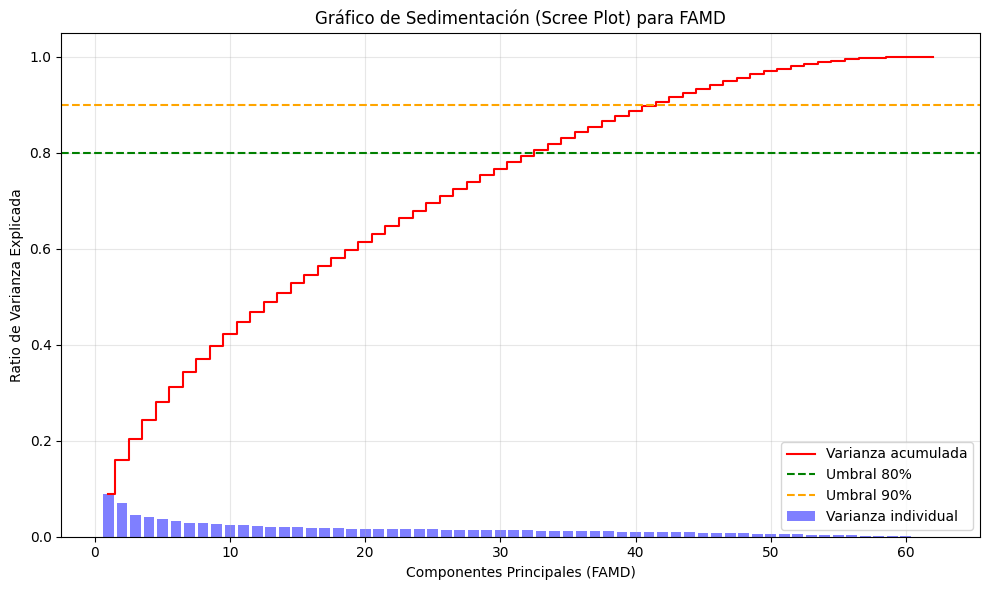

In [12]:
# 3. Graficamos
plt.figure(figsize=(10, 6))

# Gráfico de barras para la varianza de cada componente individual
plt.bar(range(1, len(varianza_individual) + 1), varianza_individual, alpha=0.5, align='center',
        label='Varianza individual', color='blue')

# Gráfico de línea para la varianza acumulada
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid',
         label='Varianza acumulada', color='red')

# Añadimos líneas de referencia (ej. 80% y 90% de la información)
plt.axhline(y=0.80, color='g', linestyle='--', label='Umbral 80%')
plt.axhline(y=0.90, color='orange', linestyle='--', label='Umbral 90%')

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales (FAMD)')
plt.title('Gráfico de Sedimentación (Scree Plot) para FAMD')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Iniciando evaluación exhaustiva (FAMD + KMeans)...

[ Entrenando FAMD con 3 variables ]
Info retenida: 20.3%
  -> Para K=2 | Silhouette Score: 0.2804
  -> Para K=3 | Silhouette Score: 0.3031
  -> Para K=4 | Silhouette Score: 0.2684
  -> Para K=5 | Silhouette Score: 0.2684

[ Entrenando FAMD con 5 variables ]
Info retenida: 28.0%
  -> Para K=2 | Silhouette Score: 0.2273
  -> Para K=3 | Silhouette Score: 0.2218
  -> Para K=4 | Silhouette Score: 0.2004
  -> Para K=5 | Silhouette Score: 0.1693

[ Entrenando FAMD con 7 variables ]
Info retenida: 34.0%
  -> Para K=2 | Silhouette Score: 0.1840
  -> Para K=3 | Silhouette Score: 0.1839
  -> Para K=4 | Silhouette Score: 0.1676
  -> Para K=5 | Silhouette Score: 0.1601

[ Entrenando FAMD con 10 variables ]
Info retenida: 42.1%
  -> Para K=2 | Silhouette Score: 0.1696
  -> Para K=3 | Silhouette Score: 0.1453
  -> Para K=4 | Silhouette Score: 0.1291
  -> Para K=5 | Silhouette Score: 0.1021

[ Entrenando FAMD con 12 variables ]
Info retenida: 46.6%
 

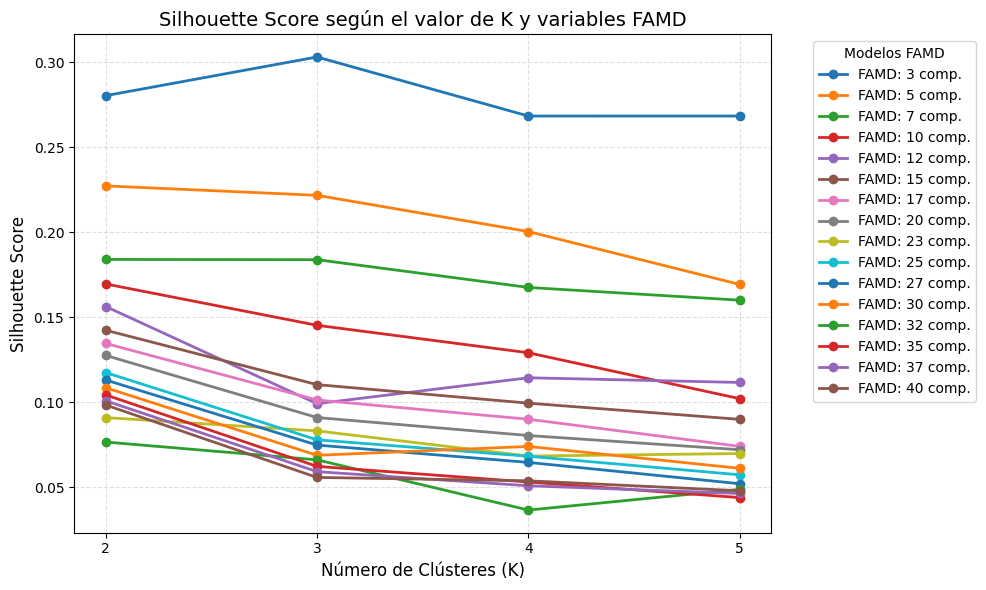

In [14]:
componentes_a_probar = [3, 5, 7, 10, 12, 15, 17, 20, 23, 25, 27, 30, 32, 35, 37, 40]

rango_k = range(2, 6) # K desde 2 hasta 6 (el 7 no se incluye)

# Diccionario para guardar los resultados y graficarlos luego
resultados_grid = {}

print("Iniciando evaluación exhaustiva (FAMD + KMeans)...")
print("=" * 60)

# Bucle externo: Iteramos sobre el número de componentes FAMD
for n_famd in componentes_a_probar:
    print(f"\n[ Entrenando FAMD con {n_famd} variables ]")
    
    # 1. Aplicar FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_reducido = famd_temp.fit_transform(trainset_no_ohe) 
    
    # 2. Extraer la información retenida (manejo de versiones de prince)
    try:
        varianza_array = np.array(famd_temp.percentage_of_variance_)
        varianza_retenida = varianza_array.sum()
        if varianza_retenida <= 1.5: 
            varianza_retenida *= 100
    except AttributeError:
        varianza_retenida = sum(famd_temp.explained_inertia_) * 100
        
    print(f"Info retenida: {varianza_retenida:.1f}%")
    
    # Lista para guardar los scores de este modelo FAMD
    scores_k = []
    
    # Bucle interno: Iteramos sobre el número de clústeres (K)
    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_reducido)
        
        score = silhouette_score(X_reducido, labels)
        scores_k.append(score)
        
        print(f"  -> Para K={k} | Silhouette Score: {score:.4f}")
        
    # Guardamos los resultados en el diccionario
    resultados_grid[n_famd] = scores_k

print("\n" + "=" * 60)
print("Generando gráfico de resultados...")

# 3. Graficar los resultados
plt.figure(figsize=(10, 6))

# Dibujar una línea por cada valor de componentes FAMD probado
for n_famd, scores in resultados_grid.items():
    plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('Silhouette Score según el valor de K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k)) # Asegurar que el eje X muestre solo enteros (2, 3, 4, 5, 6)

# Poner la leyenda fuera del gráfico para que no tape las líneas
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## K-Medioids (CLARA)

CLARA es simplemente el algoritmo PAM ejecutado sobre múltiples muestras aleatorias

In [7]:
import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np
import pandas as pd

In [8]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [20]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Calculando la matriz de Distancia de Gower...


In [22]:
resultados_pam = {}
mejor_k_pam = -1
mejor_score_pam = -1

for k in range(2, 6):
    # Usamos el algoritmo PAM clásico
    km = kmedoids.KMedoids(n_clusters=k, method='pam', random_state=42)
    c = km.fit(matriz_distancias_gower)
    labels_pam = c.labels_
    
    score_pam = silhouette_score(matriz_distancias_gower, labels_pam, metric='precomputed')
    resultados_pam[k] = score_pam
    print(f"PAM -> Para K={k} | Silhouette Score (Gower): {score_pam:.4f}")
    
    if score_pam > mejor_score_pam:
        mejor_score_pam = score_pam
        mejor_k_pam = k

print(f"🏆 Mejor K para PAM: {mejor_k_pam} (Score: {mejor_score_pam:.4f})")

print("\n" + "="*60)
print("2. EVALUACIÓN CON CLUSTERING JERÁRQUICO AGLOMERATIVO")
print("="*60)

PAM -> Para K=2 | Silhouette Score (Gower): 0.0911
PAM -> Para K=3 | Silhouette Score (Gower): 0.0970
PAM -> Para K=4 | Silhouette Score (Gower): 0.0822
PAM -> Para K=5 | Silhouette Score (Gower): 0.0755
🏆 Mejor K para PAM: 3 (Score: 0.0970)

2. EVALUACIÓN CON CLUSTERING JERÁRQUICO AGLOMERATIVO


### Aplicando reducción de dimensionalidad FAMD


1. EVALUACIÓN EXHAUSTIVA: K-MEDOIDS (PAM) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3495
  -> K=3 | Silhouette: 0.3986
  -> K=4 | Silhouette: 0.3729
  -> K=5 | Silhouette: 0.3408

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.2747
  -> K=3 | Silhouette: 0.2975
  -> K=4 | Silhouette: 0.2793
  -> K=5 | Silhouette: 0.2618

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2328
  -> K=3 | Silhouette: 0.2536
  -> K=4 | Silhouette: 0.2104
  -> K=5 | Silhouette: 0.2040

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.1936
  -> K=3 | Silhouette: 0.2175
  -> K=4 | Silhouette: 0.1831
  -> K=5 | Silhouette: 0.1802

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.1794
  -> K=3 | Silhouette: 0.1791
  -> K=4 | Silhouette: 0.1441
  -> K=5 | Silhouette: 0.1606

[ Entrenando FAMD con  7 variables ]
  -> K=2 | Silhouette: 0.1624
  -> K=3 | Silhouette: 0.1727
  -> K=4 | Silhouette: 0.1368
  -> K=5 | Silhou

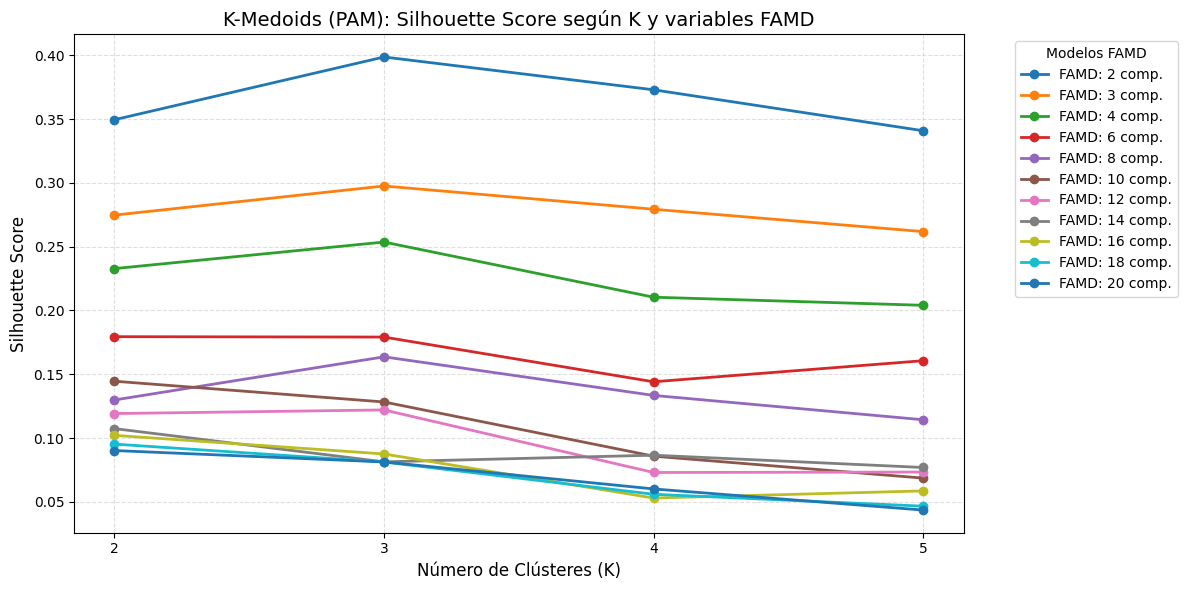

In [21]:
print("\n" + "="*60)
print("1. EVALUACIÓN EXHAUSTIVA: K-MEDOIDS (PAM) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionario para guardar los resultados y graficarlos
resultados_silhouette_pam = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global_pam = -1
mejor_k_global_pam = -1
mejor_famd_global_pam = -1

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")
    
    # 1. Reducir dimensionalidad con FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()
    
    scores_sil_k = []
    
    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        # Al usar matriz_famd (coordenadas continuas), PAM usará distancia Euclidiana internamente
        km = kmedoids.KMedoids(n_clusters=k, method='pam', metric='euclidean', random_state=42)
        c = km.fit(matriz_famd)
        labels_pam = c.labels_
        
        # OJO: Calculamos el Silhouette sobre la matriz continua de FAMD, ya NO usamos Gower
        score_pam = silhouette_score(matriz_famd, labels_pam, metric='euclidean')
        scores_sil_k.append(score_pam)
        
        print(f"  -> K={k} | Silhouette: {score_pam:.4f}")
        
        # Actualizar el campeón absoluto
        if score_pam > mejor_score_global_pam:
            mejor_score_global_pam = score_pam
            mejor_k_global_pam = k
            mejor_famd_global_pam = n_famd

    # Guardar en diccionario para la gráfica
    resultados_silhouette_pam[n_famd] = scores_sil_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO PAM: FAMD = {mejor_famd_global_pam} comp. | K = {mejor_k_global_pam}")
print(f"   (Silhouette Score: {mejor_score_global_pam:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_pam.items():
    # Mostramos líneas pares o el 3 para no saturar el gráfico visualmente
    if n_famd % 2 == 0 or n_famd == 3: 
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('K-Medoids (PAM): Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## Custering Jerarquico Aglomerativo

### Sin Reducción de dimensionalidad (FAMD)

In [ ]:
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Jerárquico -> Para K=2 | Silhouette Score (Gower): 0.3110
Jerárquico -> Para K=3 | Silhouette Score (Gower): 0.2218
Jerárquico -> Para K=4 | Silhouette Score (Gower): 0.1944
Jerárquico -> Para K=5 | Silhouette Score (Gower): 0.1684
🏆 Mejor K para Jerárquico: 2 (Score: 0.3110)


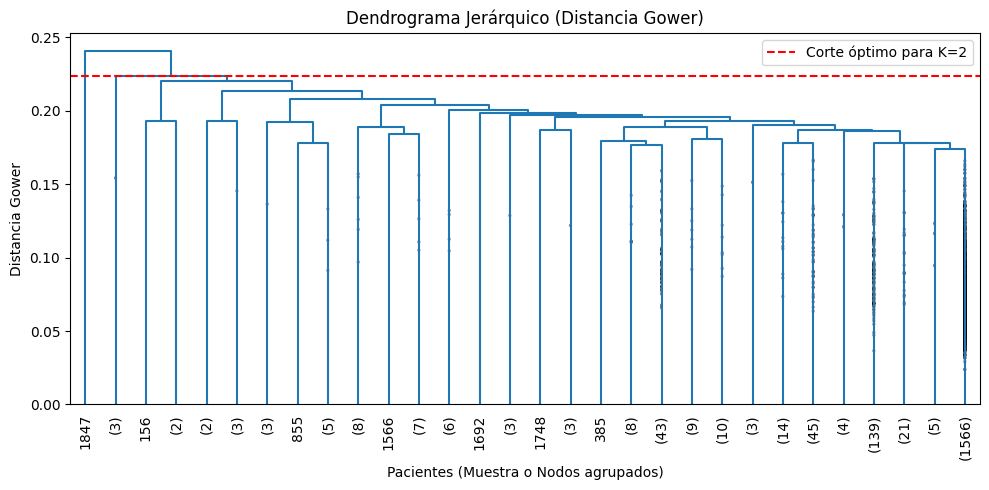

In [ ]:
resultados_jer = {}
mejor_k_jer = -1
mejor_score_jer = -1

for k in range(2, 6):
    # linkage='average' es ideal para distancias no euclidianas como Gower
    jerarquico = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels_jer = jerarquico.fit_predict(matriz_distancias_gower)
    
    score_jer = silhouette_score(matriz_distancias_gower, labels_jer, metric='precomputed')
    resultados_jer[k] = score_jer
    print(f"Jerárquico -> Para K={k} | Silhouette Score (Gower): {score_jer:.4f}")
    
    if score_jer > mejor_score_jer:
        mejor_score_jer = score_jer
        mejor_k_jer = k

print(f"🏆 Mejor K para Jerárquico: {mejor_k_jer} (Score: {mejor_score_jer:.4f})")

# Graficar el Dendrograma
gower_condensada = ssd.squareform(matriz_distancias_gower)
Z = linkage(gower_condensada, method='average')

plt.figure(figsize=(10, 5))
plt.title('Dendrograma Jerárquico (Distancia Gower)')
plt.xlabel('Pacientes (Muestra o Nodos agrupados)')
plt.ylabel('Distancia Gower')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
if mejor_k_jer > 1: # Prevenir error de índice
    plt.axhline(y=Z[-mejor_k_jer, 2], color='r', linestyle='--', label=f'Corte óptimo para K={mejor_k_jer}')
plt.legend()
plt.tight_layout()
plt.show()

Clustering jerarquico CON FAMD


2. EVALUACIÓN EXHAUSTIVA: JERÁRQUICO (WARD) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3542
  -> K=3 | Silhouette: 0.3506
  -> K=4 | Silhouette: 0.3408
  -> K=5 | Silhouette: 0.3150

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.2402
  -> K=3 | Silhouette: 0.2454
  -> K=4 | Silhouette: 0.2254
  -> K=5 | Silhouette: 0.2247

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2151
  -> K=3 | Silhouette: 0.2139
  -> K=4 | Silhouette: 0.1840
  -> K=5 | Silhouette: 0.1918

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.1982
  -> K=3 | Silhouette: 0.1744
  -> K=4 | Silhouette: 0.1793
  -> K=5 | Silhouette: 0.1755

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.1476
  -> K=3 | Silhouette: 0.1744
  -> K=4 | Silhouette: 0.1826
  -> K=5 | Silhouette: 0.1853

[ Entrenando FAMD con  7 variables ]
  -> K=2 | Silhouette: 0.1823
  -> K=3 | Silhouette: 0.1388
  -> K=4 | Silhouette: 0.1428
  -> K=5 | Silh

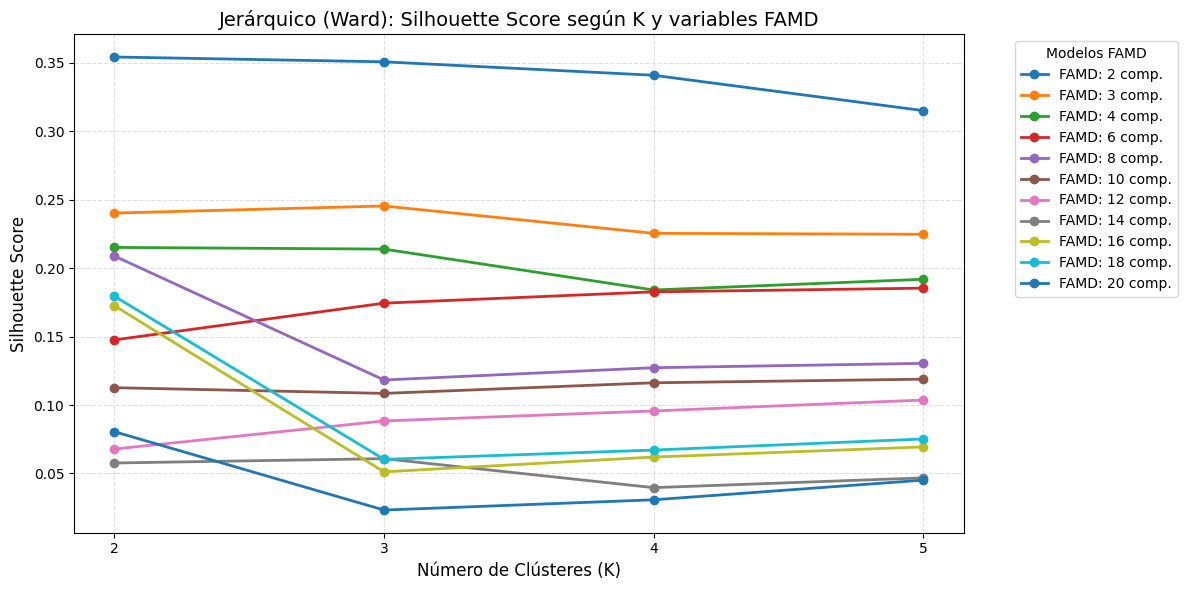


Generando Dendrograma para el modelo óptimo...


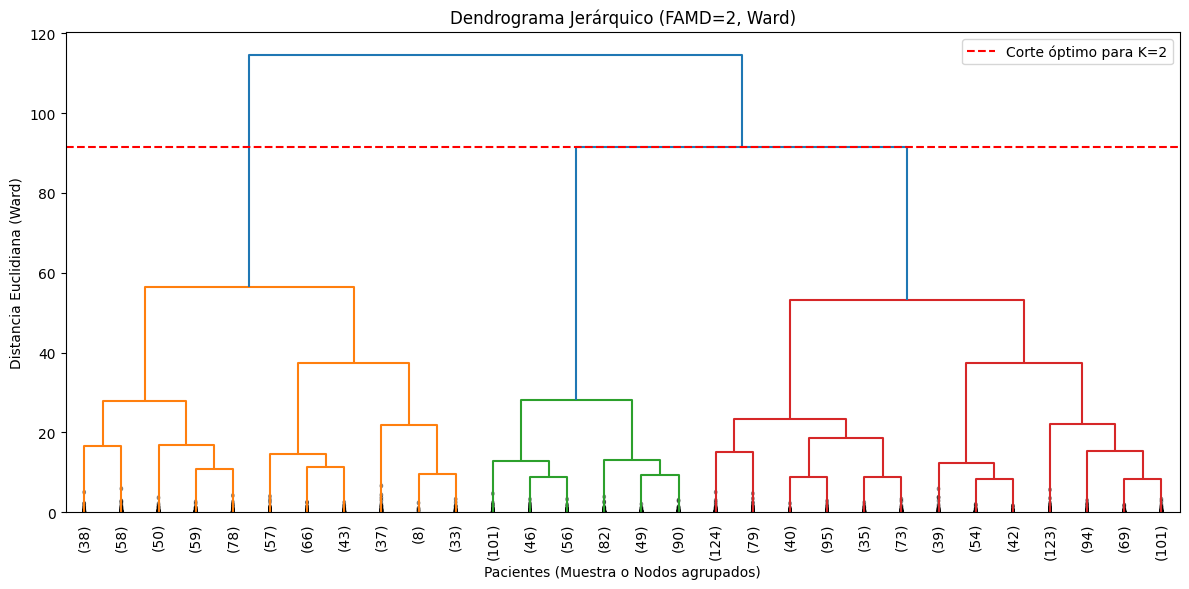

In [20]:
print("\n" + "="*60)
print("2. EVALUACIÓN EXHAUSTIVA: JERÁRQUICO (WARD) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionario para guardar los resultados (para la gráfica)
resultados_silhouette_jer = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global_jer = -1
mejor_k_global_jer = -1
mejor_famd_global_jer = -1

# Variable para guardar las coordenadas FAMD del mejor modelo (para el dendrograma)
mejor_matriz_famd = None 

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")
    
    # 1. Reducir dimensionalidad con FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()
    
    scores_sil_k = []
    
    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        # Usamos Euclidean y Ward, ideal para el espacio numérico continuo de FAMD
        jer_famd = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels_jer_famd = jer_famd.fit_predict(matriz_famd)
        
        score_jer_famd = silhouette_score(matriz_famd, labels_jer_famd)
        scores_sil_k.append(score_jer_famd)
        
        print(f"  -> K={k} | Silhouette: {score_jer_famd:.4f}")
        
        # Actualizar el campeón absoluto
        if score_jer_famd > mejor_score_global_jer:
            mejor_score_global_jer = score_jer_famd
            mejor_k_global_jer = k
            mejor_famd_global_jer = n_famd
            mejor_matriz_famd = matriz_famd # Guardamos la matriz ganadora para graficar luego

    # Guardar en diccionario para la gráfica
    resultados_silhouette_jer[n_famd] = scores_sil_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO JERÁRQUICO: FAMD = {mejor_famd_global_jer} comp. | K = {mejor_k_global_jer}")
print(f"   (Silhouette Score: {mejor_score_global_jer:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_jer.items():
    # Solo mostramos líneas pares o de 5 en 5 para no saturar el gráfico
    if n_famd % 2 == 0 or n_famd == 3: 
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('Jerárquico (Ward): Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAFICAR EL DENDROGRAMA ÓPTIMO
# ---------------------------------------------------------
print("\nGenerando Dendrograma para el modelo óptimo...")
# Para ward con datos continuos, le pasamos la matriz directamente a linkage
Z_ward = linkage(mejor_matriz_famd, method='ward')

plt.figure(figsize=(12, 6))
plt.title(f'Dendrograma Jerárquico (FAMD={mejor_famd_global_jer}, Ward)')
plt.xlabel('Pacientes (Muestra o Nodos agrupados)')
plt.ylabel('Distancia Euclidiana (Ward)')
# truncate_mode para no colapsar la gráfica
dendrogram(Z_ward, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
if mejor_k_global_jer > 1:
    # Dibujar la línea de corte horizontal
    plt.axhline(y=Z_ward[-mejor_k_global_jer, 2], color='r', linestyle='--', label=f'Corte óptimo para K={mejor_k_global_jer}')
plt.legend()
plt.tight_layout()
plt.show()

## GAUSSIAN MIXTURE MODELS

Aplicando FAMD para reducción de dimensionalidad


3. EVALUACIÓN EXHAUSTIVA: GMM (K=2 a 5) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3372 | BIC: 16958
  -> K=3 | Silhouette: 0.3959 | BIC: 16767
  -> K=4 | Silhouette: 0.3668 | BIC: 16779
  -> K=5 | Silhouette: 0.3433 | BIC: 16817

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.3001 | BIC: 24281
  -> K=3 | Silhouette: 0.2936 | BIC: 24108
  -> K=4 | Silhouette: 0.2308 | BIC: 24146
  -> K=5 | Silhouette: 0.2457 | BIC: 24161

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2738 | BIC: 30972
  -> K=3 | Silhouette: 0.2360 | BIC: 30794
  -> K=4 | Silhouette: 0.2095 | BIC: 30731
  -> K=5 | Silhouette: 0.1679 | BIC: 30783

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.2643 | BIC: 37662
  -> K=3 | Silhouette: 0.1993 | BIC: 37430
  -> K=4 | Silhouette: 0.1873 | BIC: 37405
  -> K=5 | Silhouette: 0.1589 | BIC: 37327

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.3079 | BIC: 43084
  -> K=3 | Silho

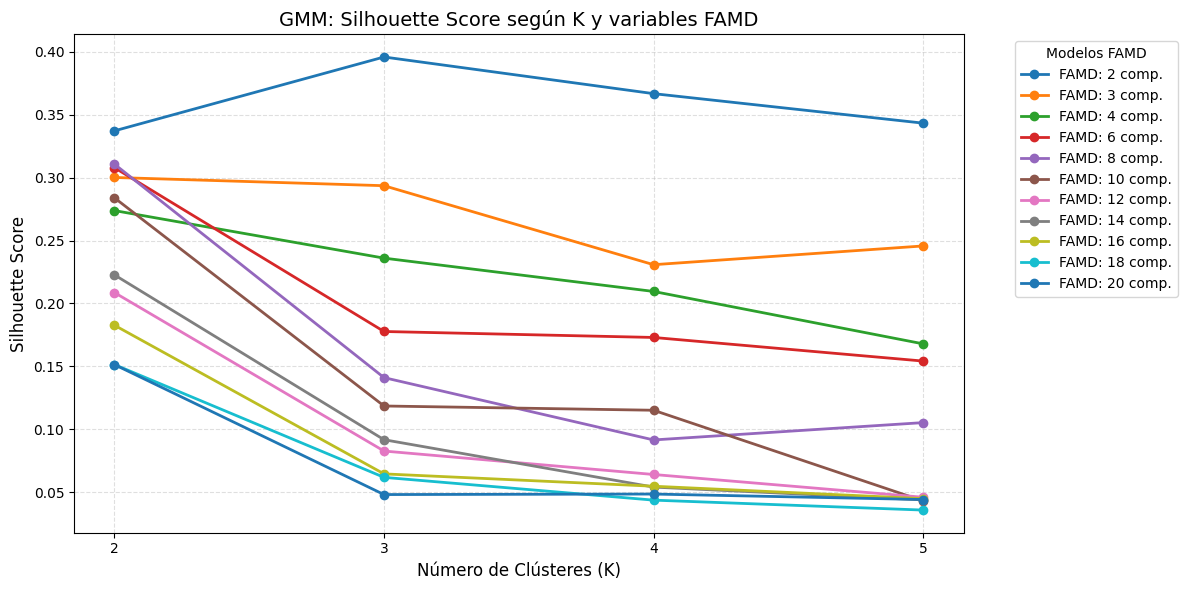

In [11]:
print("\n" + "="*60)
print("3. EVALUACIÓN EXHAUSTIVA: GMM (K=2 a 5) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionarios para guardar los resultados y graficar después
resultados_silhouette_gmm = {}
resultados_bic_gmm = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global = -1
mejor_k_global = -1
mejor_famd_global = -1

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")
    
    # 1. Reducir dimensionalidad
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()
    
    scores_sil_k = []
    scores_bic_k = []
    
    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        labels_gmm = gmm.fit_predict(matriz_famd)
        
        score_gmm = silhouette_score(matriz_famd, labels_gmm)
        bic_score = gmm.bic(matriz_famd)
        
        scores_sil_k.append(score_gmm)
        scores_bic_k.append(bic_score)
        
        print(f"  -> K={k} | Silhouette: {score_gmm:.4f} | BIC: {bic_score:.0f}")
        
        # Actualizar el campeón absoluto
        if score_gmm > mejor_score_global:
            mejor_score_global = score_gmm
            mejor_k_global = k
            mejor_famd_global = n_famd

    # Guardar en diccionarios
    resultados_silhouette_gmm[n_famd] = scores_sil_k
    resultados_bic_gmm[n_famd] = scores_bic_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO GMM: FAMD = {mejor_famd_global} comp. | K = {mejor_k_global}")
print(f"   (Silhouette Score: {mejor_score_global:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_gmm.items():
    # Solo mostramos líneas pares o de 5 en 5 para no saturar el gráfico
    if n_famd % 2 == 0 or n_famd == 3: 
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('GMM: Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()